<a href="https://colab.research.google.com/github/VitorMiller/VitorMiller-Redes-Neurais-ArtificiaisMPCA/blob/main/Classificar_o_MNIST_original_Vitor_Miller_Tarefa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import gzip
import struct
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
from pathlib import Path
import urllib.request

DATA_DIR = Path("mnist_original")
DATA_DIR.mkdir(exist_ok=True)

FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz"
}

MNIST_SOURCE = "https://raw.githubusercontent.com/fgnt/mnist/master"


def download_file(filename, data_dir=DATA_DIR):
    output_path = data_dir / filename

    if output_path.exists():
        print(f"Arquivo já existe: {output_path}")
        return output_path

    url = f"{MNIST_SOURCE}/{filename}"

    print(f"Baixando: {url}")
    urllib.request.urlretrieve(url, output_path)
    print(f"Baixado com sucesso: {output_path}")

    return output_path


paths = {name: download_file(filename) for name, filename in FILES.items()}

paths

Baixando: https://raw.githubusercontent.com/fgnt/mnist/master/train-images-idx3-ubyte.gz
Baixado com sucesso: mnist_original/train-images-idx3-ubyte.gz
Baixando: https://raw.githubusercontent.com/fgnt/mnist/master/train-labels-idx1-ubyte.gz
Baixado com sucesso: mnist_original/train-labels-idx1-ubyte.gz
Baixando: https://raw.githubusercontent.com/fgnt/mnist/master/t10k-images-idx3-ubyte.gz
Baixado com sucesso: mnist_original/t10k-images-idx3-ubyte.gz
Baixando: https://raw.githubusercontent.com/fgnt/mnist/master/t10k-labels-idx1-ubyte.gz
Baixado com sucesso: mnist_original/t10k-labels-idx1-ubyte.gz


{'train_images': PosixPath('mnist_original/train-images-idx3-ubyte.gz'),
 'train_labels': PosixPath('mnist_original/train-labels-idx1-ubyte.gz'),
 'test_images': PosixPath('mnist_original/t10k-images-idx3-ubyte.gz'),
 'test_labels': PosixPath('mnist_original/t10k-labels-idx1-ubyte.gz')}

In [3]:
def read_idx_images(path):
    with gzip.open(path, "rb") as f:
        magic, n_images, rows, cols = struct.unpack(">IIII", f.read(16))

        if magic != 2051:
            raise ValueError(f"Arquivo de imagens inválido. Magic number encontrado: {magic}")

        data = np.frombuffer(f.read(), dtype=np.uint8)
        images = data.reshape(n_images, rows, cols)

    return images


def read_idx_labels(path):
    with gzip.open(path, "rb") as f:
        magic, n_labels = struct.unpack(">II", f.read(8))

        if magic != 2049:
            raise ValueError(f"Arquivo de labels inválido. Magic number encontrado: {magic}")

        labels = np.frombuffer(f.read(), dtype=np.uint8)

    return labels


train_images = read_idx_images(paths["train_images"])
train_labels = read_idx_labels(paths["train_labels"])
test_images = read_idx_images(paths["test_images"])
test_labels = read_idx_labels(paths["test_labels"])

print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images:", test_images.shape)
print("test_labels:", test_labels.shape)
print("Valores dos pixels:", train_images.min(), "até", train_images.max())
print("Classes:", np.unique(train_labels))

train_images: (60000, 28, 28)
train_labels: (60000,)
test_images: (10000, 28, 28)
test_labels: (10000,)
Valores dos pixels: 0 até 255
Classes: [0 1 2 3 4 5 6 7 8 9]


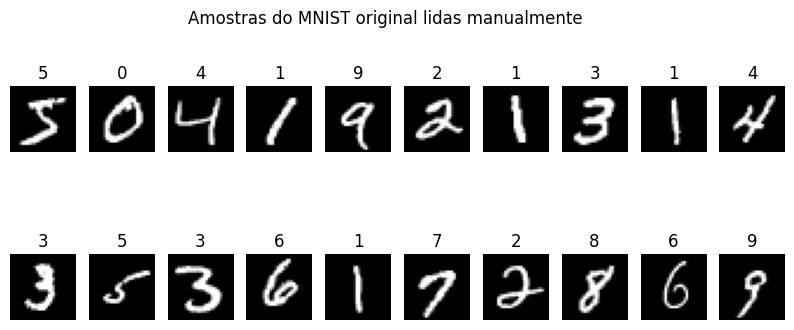

In [4]:
plt.figure(figsize=(10, 4))

for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(str(train_labels[i]))
    plt.axis("off")

plt.suptitle("Amostras do MNIST original lidas manualmente")
plt.show()

In [5]:
X_train = train_images.astype("float32") / 255.0
X_test = test_images.astype("float32") / 255.0

X_train = X_train.reshape((-1, 28, 28, 1))
X_test = X_test.reshape((-1, 28, 28, 1))

y_train = train_labels.astype("int64")
y_test = test_labels.astype("int64")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Valor mínimo após normalização:", X_train.min())
print("Valor máximo após normalização:", X_train.max())

X_train: (60000, 28, 28, 1)
X_test: (10000, 28, 28, 1)
y_train: (60000,)
y_test: (10000,)
Valor mínimo após normalização: 0.0
Valor máximo após normalização: 1.0


In [6]:
def KerasCNN2D(input_shape=(28, 28, 1), num_classes=10):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
    x = layers.Flatten()(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs=inputs, outputs=outputs)


model = KerasCNN2D(input_shape=(28, 28, 1), num_classes=10)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 99ms/step - accuracy: 0.9235 - loss: 0.2536 - val_accuracy: 0.9833 - val_loss: 0.0612
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9812 - loss: 0.0618 - val_accuracy: 0.9852 - val_loss: 0.0526
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9865 - loss: 0.0433 - val_accuracy: 0.9888 - val_loss: 0.0414
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9902 - loss: 0.0325 - val_accuracy: 0.9905 - val_loss: 0.0392
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 96ms/step - accuracy: 0.9922 - loss: 0.0261 - val_accuracy: 0.9902 - val_loss: 0.0370


In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Loss no teste: {test_loss:.4f}")
print(f"Acurácia no teste: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9898 - loss: 0.0283
Loss no teste: 0.0283
Acurácia no teste: 0.9898


In [9]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("Acurácia calculada com accuracy_score:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
Acurácia calculada com accuracy_score: 0.9898

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



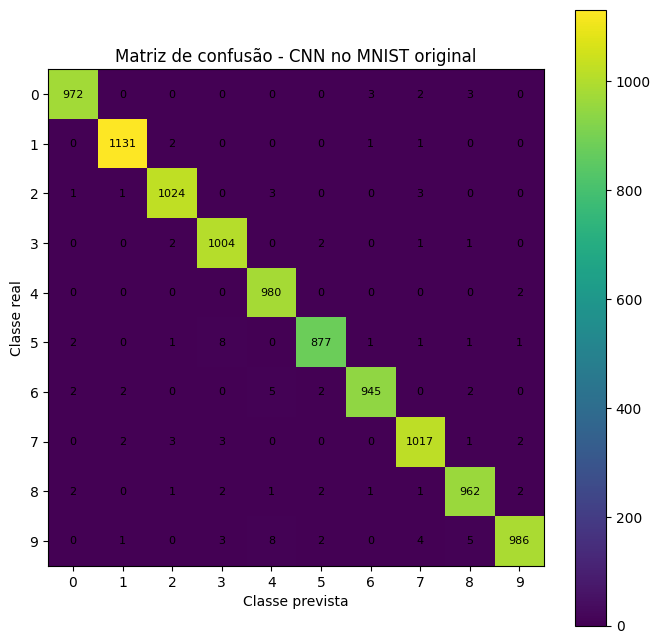

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Matriz de confusão - CNN no MNIST original")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

Usando Pipeline semelhante ao da aula

In [11]:
class Divide255(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.astype("float32") / 255.0


class Shape2Keras(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.reshape((-1, 28, 28, 1))


class KerasWrappedCNN(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=5, batch_size=128, model_fabric=KerasCNN2D):
        self.epochs = epochs
        self.batch_size = batch_size
        self.model_fabric = model_fabric

    def fit(self, X, y):
        self.labels_ = np.unique(y)
        self.classes_ = self.labels_

        self.model_ = self.model_fabric(
            input_shape=X.shape[1:],
            num_classes=len(self.labels_)
        )

        self.model_.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        self.model_.fit(
            X,
            y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_split=0.1
        )

        self.is_fitted_ = True

        return self

    def predict(self, X):
        y_pred = self.model_.predict(X)
        return self.labels_[np.argmax(y_pred, axis=1)]


pipeline = Pipeline([
    ("scaler", Divide255()),
    ("shape", Shape2Keras()),
    ("model", KerasWrappedCNN(epochs=5, batch_size=128, model_fabric=KerasCNN2D))
])

pipeline.fit(train_images, train_labels)

pipeline_pred = pipeline.predict(test_images)
pipeline_acc = accuracy_score(test_labels, pipeline_pred)

print(f"Acurácia da CNN usando Pipeline: {pipeline_acc:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 100ms/step - accuracy: 0.9272 - loss: 0.2484 - val_accuracy: 0.9847 - val_loss: 0.0561
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9811 - loss: 0.0591 - val_accuracy: 0.9875 - val_loss: 0.0417
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 97ms/step - accuracy: 0.9871 - loss: 0.0408 - val_accuracy: 0.9898 - val_loss: 0.0349
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9901 - loss: 0.0311 - val_accuracy: 0.9915 - val_loss: 0.0315
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9924 - loss: 0.0242 - val_accuracy: 0.9912 - val_loss: 0.0318
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Acurácia da CNN usando Pipeline: 0.9919
